### **Human in the loop**

In [68]:
from dotenv import load_dotenv, find_dotenv
import os, openai
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults

_ = load_dotenv(find_dotenv())
openai.api_key = os.environ['OPENAI_API_KEY']

chat = ChatOpenAI(model = 'gpt-3.5-turbo')
tool = TavilySearchResults(max_results = 2)

In [69]:
from uuid import uuid4
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage, SystemMessage, ToolMessage
from typing import TypedDict, Annotated, Literal


memory = MemorySaver()

'''
In previous examples we've annotated the `messages` state key
with the default `operator.add` or `+` reducer, which always
appends new messages to the end of the existing messages array.

Now, to support replacing existing messages, we annotate the
`messages` key with a customer reducer function, which replaces
messages with the same `id`, and appends them otherwise.
'''

def reduce_messages(left: list[AnyMessage], right: list[AnyMessage]) -> list[AnyMessage]:
    # assign ids to messages that don't have them
    for message in right:
        if not message.id:
            message.id = str(uuid4())
    # merge the new messages with the existing messages
    merged = left.copy()
    for message in right:
        for i, existing in enumerate(merged):
            # replace any existing messages with the same id
            if existing.id == message.id:
                merged[i] = message
                break
        else:
            # append any new messages to the end
            merged.append(message)
    return merged

class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], reduce_messages]

#### **Manual human approval**

In [70]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END

memory = MemorySaver()

class Agent:
    def __init__(self, chat, tools, system = '', checkpointer = None):
        builder = StateGraph(AgentState)
        builder.add_node('Large Language Model', self.call_openai)
        builder.add_node('Action', self.take_action)

        builder.set_entry_point('Large Language Model')
        builder.add_conditional_edges('Large Language Model', self.thought)
        builder.add_edge('Action', 'Large Language Model')
        self.graph = builder.compile(
            checkpointer = checkpointer,
            interrupt_before = ['Action']
        )

        self.system = system
        self.tools = {t.name: t for t in tools}
        self.chat = chat.bind_tools(tools)

    def thought (self, state: AgentState) -> Literal['Action', END]:
        response = state['messages'][-1]
        return 'Action' if len(response.tool_calls) > 0 else END
    
    def call_openai(self, state: AgentState):
        messages = state['messages']
        if self.system:
            messages = [SystemMessage(content = self.system)] + messages
        message = self.chat.invoke(messages)
        return {'messages': [message]}
    
    def take_action(self, state: AgentState):
        tool_calls = state['messages'][-1].tool_calls
        response = []

        for t in tool_calls:
            print(f'Calling: {t}')
            output = self.tools[t['name']].invoke(t['args'])
            response.append(ToolMessage(tool_call_id = t['id'], name = t['name'], content = str(output)))

        print('Back to the model!')
        return {'messages': response}

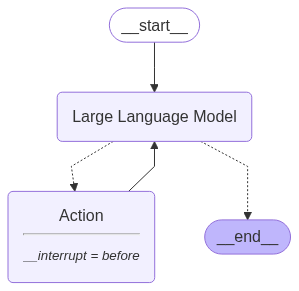

In [71]:
from IPython.display import display, Image

prompt = '''You are a smart research assistant. Use the search engine to look up information. \
You are allowed to make multiple calls (either together or in sequence). \
Only look up information when you are sure of what you want. \
If you need to look up some information before asking a follow up question, you are allowed to do that!
'''

AIbot = Agent(chat, [tool], system = prompt, checkpointer = memory)
display(Image(AIbot.graph.get_graph().draw_mermaid_png()))

In [59]:
messages = [HumanMessage(content = 'What is the weather today in the capital of France?')]
thread = {'configurable': {'thread_id': '1'}}

for event in AIbot.graph.stream({'messages': messages}, thread):
    for v in event.values():
        print(v)

{'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_F07TuqjfTXWe1XJuTFkv8Psb', 'function': {'arguments': '{"query":"weather today in Paris, France"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 460, 'total_tokens': 483, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-BclIVh4MZ5GtlPvUQytDYzQcFPF1E', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--a38aff5d-e872-4802-b6b0-22469581673e-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'weather today in Paris, France'}, 'id': 'call_F07TuqjfTXWe1XJuTFkv8Psb', 'type': 'tool_call'}], usage_metadata={'input_to

In [38]:
AIbot.graph.get_state(thread)

StateSnapshot(values={'messages': [HumanMessage(content='What is the weather today in the capital of France?', additional_kwargs={}, response_metadata={}, id='bdce25fb-5abf-4ce8-a152-9288e4ecc0ad'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_mRoYxrx1O20EI3DVUsPXn02A', 'function': {'arguments': '{"query":"weather today in Paris, France"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 157, 'total_tokens': 180, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-BckeZGIHd8NCfY7MrjEZv5VWu6ZwD', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--cc499be6-585c-4e23-b19a-7b1d1632d4ba-0', tool_c

In [40]:
AIbot.graph.get_state(thread).next

('Action',)

##### **continue after interrupt**

In [60]:
for event in AIbot.graph.stream(None, thread):
    for v in event.values():
        print(v)

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'weather today in Paris, France'}, 'id': 'call_F07TuqjfTXWe1XJuTFkv8Psb', 'type': 'tool_call'}
Back to the model!
{'messages': [ToolMessage(content="[{'title': 'Weather in Paris in May 2025 (Île-de-France) - World-Weather.info', 'url': 'https://world-weather.info/forecast/france/paris/may-2025/', 'content': 'Weather in Paris in May 2025. Paris Weather Forecast for May 2025 is based on ... Friday, 30 May. +64°. Day. +79°. Clear sky. Saturday, 31 May. +70°. Day. +81', 'score': 0.949786}, {'title': 'Weather in Paris in May 2025 - Detailed Forecast - EaseWeather', 'url': 'https://www.easeweather.com/europe/france/ile-de-france/paris/may', 'content': '30 May. Patchy rain possible. 29° /15°, 0.3 mm, 2.2. 31 May ... France · Île-de-France · Paris · May. Location coordinates Where is Paris? Get', 'score': 0.8961153}]", name='tavily_search_results_json', id='0d660aa1-a08a-4681-9fc0-08445444fed1', tool_call_id='call_F07TuqjfTXWe1X

In [42]:
AIbot.graph.get_state(thread)

StateSnapshot(values={'messages': [HumanMessage(content='What is the weather today in the capital of France?', additional_kwargs={}, response_metadata={}, id='bdce25fb-5abf-4ce8-a152-9288e4ecc0ad'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_mRoYxrx1O20EI3DVUsPXn02A', 'function': {'arguments': '{"query":"weather today in Paris, France"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 157, 'total_tokens': 180, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-BckeZGIHd8NCfY7MrjEZv5VWu6ZwD', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--cc499be6-585c-4e23-b19a-7b1d1632d4ba-0', tool_c

In [43]:
AIbot.graph.get_state(thread).next

()

In [45]:
messages = [HumanMessage('Whats the weather in Los Angeles?')]
thread = {'configurable': {'thread_id': '2'}}

for event in AIbot.graph.stream({'messages': messages}, thread):
    for v in event.values():
        print(v)

while AIbot.graph.get_state(thread).next:
    print('\n', AIbot.graph.get_state(thread), '\n')
    _input = input('proceed? ')
    if _input != 'y':
        print('aborting')
        break
    for event in AIbot.graph.stream(None, thread):
        for v in event.values():
            print(v)

{'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_HRJXmoohcZqYXrc3C2hwp8pk', 'function': {'arguments': '{"query":"current weather in Los Angeles"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 1069, 'total_tokens': 1091, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-Bcl4GsqyeCVFlgeq1wfmerhSnSrC6', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--532a38ab-97a4-48fb-ae99-7f268ed21e15-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'current weather in Los Angeles'}, 'id': 'call_HRJXmoohcZqYXrc3C2hwp8pk', 'type': 'tool_call'}], usage_metadata={'input_

#### **Modify State**

In [72]:
messages = [HumanMessage('Whats the weather in LA?')]
thread = {'configurable': {'thread_id': '3'}}

for event in AIbot.graph.stream({'messages': messages}, thread):
    for v in event.values():
        print(v)

{'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_vHKxWo81QZNnkCfSAU8gCF3Q', 'function': {'arguments': '{"query":"weather in Los Angeles"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 152, 'total_tokens': 173, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-BclQPGRKYvkAkvfRtFgBknUc9RqNR', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--6c9b9da6-6d2a-4365-9757-c358647d6ed3-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'weather in Los Angeles'}, 'id': 'call_vHKxWo81QZNnkCfSAU8gCF3Q', 'type': 'tool_call'}], usage_metadata={'input_tokens': 152, 'out

In [47]:
AIbot.graph.get_state(thread)

StateSnapshot(values={'messages': [HumanMessage(content='Whats the weather in LA?', additional_kwargs={}, response_metadata={}, id='3ce4babe-445c-432e-8bdf-0a0e83cea949'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_BZOSnYbn1vFwQ3hbV3wUehF5', 'function': {'arguments': '{"query":"current weather in Los Angeles"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 152, 'total_tokens': 174, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-Bcl6Xzc9SKYDhnmDGtCYvmEFOqxla', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--a7dd28ba-2a3b-4e27-a04b-56da44aae811-0', tool_calls=[{'name': 'tavily_sear

In [73]:
current_values = AIbot.graph.get_state(thread)
current_values.values['messages'][-1]

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_vHKxWo81QZNnkCfSAU8gCF3Q', 'function': {'arguments': '{"query":"weather in Los Angeles"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 152, 'total_tokens': 173, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-BclQPGRKYvkAkvfRtFgBknUc9RqNR', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--6c9b9da6-6d2a-4365-9757-c358647d6ed3-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'weather in Los Angeles'}, 'id': 'call_vHKxWo81QZNnkCfSAU8gCF3Q', 'type': 'tool_call'}], usage_metadata={'input_tokens': 152, 'output_tokens': 2

In [74]:
current_values.values['messages'][-1].tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'weather in Los Angeles'},
  'id': 'call_vHKxWo81QZNnkCfSAU8gCF3Q',
  'type': 'tool_call'}]

In [76]:
_id = current_values.values['messages'][-1].tool_calls[0]['id']
current_values.values['messages'][-1].tool_calls = [
    {'name': 'tavily_search_results_json',
     'args': {'query': 'current weather in the capital of France'},
     'id': _id
}]

AIbot.graph.update_state(thread, current_values.values)

{'configurable': {'thread_id': '3',
  'checkpoint_ns': '',
  'checkpoint_id': '1f03d0ca-12c6-646a-8003-f4ddd830660d'}}

`update_state()` doesn’t change the original state - instead, it generates a new branch in the conversation history

In [77]:
AIbot.graph.get_state(thread)

StateSnapshot(values={'messages': [HumanMessage(content='Whats the weather in LA?', additional_kwargs={}, response_metadata={}, id='4a23e92c-7685-4e40-890f-d58fa79b8b9b'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_vHKxWo81QZNnkCfSAU8gCF3Q', 'function': {'arguments': '{"query":"weather in Los Angeles"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 152, 'total_tokens': 173, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-BclQPGRKYvkAkvfRtFgBknUc9RqNR', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--6c9b9da6-6d2a-4365-9757-c358647d6ed3-0', tool_calls=[{'name': 'tavily_search_resul

In [78]:
for event in AIbot.graph.stream(None, thread):
    for v in event.values():
        print(v)

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'current weather in the capital of France'}, 'id': 'call_vHKxWo81QZNnkCfSAU8gCF3Q', 'type': 'tool_call'}
Back to the model!
{'messages': [ToolMessage(content="[{'title': 'Weather Paris in May 2025: Temperature & Climate', 'url': 'https://en.climate-data.org/europe/france/ile-de-france/paris-44/t/may-5/', 'content': '29. May | 16 °C | 61 °F | 20 °C | 69 °F | 11 °C | 51 °F | 2.2 mm | 0.1 inch.\\n30. May | 16 °C | 61 °F | 20 °C | 69 °F | 11 °C | 52 °F | 2.8 mm | 0.1 inch.\\n31. May | 16 °C | 60 °F | 20 °C | 68 °F | 11 °C | 52 °F | 2.7 mm | 0.1 inch.\\nAirport close to Paris [...] Precipitation / Rainfall mm (in) | 57(2) | 52(2) | 53(2) | 56(2) | 69(2) | 63(2) | 60(2) | 60(2) | 51(2) | 65(2) | 64(2) | 70(2)\\nHumidity(%) | 85% | 81% | 76% | 71% | 71% | 68% | 65% | 66% | 71% | 79% | 86% | 86%\\nRainy days (d) | 9 | 8 | 8 | 9 | 9 | 8 | 8 | 7 | 6 | 8 | 9 | 10\\navg. Sun hours (hours) | 2.9 | 4.0 | 5.8 | 8.0 | 8.6 | 9.5 | 10.0 |

#### **Time Travel**

In [79]:
states = []
for state in AIbot.graph.get_state_history(thread):
    print(state)
    print('--')
    states.append(state)

StateSnapshot(values={'messages': [HumanMessage(content='Whats the weather in LA?', additional_kwargs={}, response_metadata={}, id='4a23e92c-7685-4e40-890f-d58fa79b8b9b'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_vHKxWo81QZNnkCfSAU8gCF3Q', 'function': {'arguments': '{"query":"weather in Los Angeles"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 152, 'total_tokens': 173, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-BclQPGRKYvkAkvfRtFgBknUc9RqNR', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--6c9b9da6-6d2a-4365-9757-c358647d6ed3-0', tool_calls=[{'name': 'tavily_search_resul

In [96]:
to_replay = states[-3]
to_replay

StateSnapshot(values={'messages': [HumanMessage(content='Whats the weather in LA?', additional_kwargs={}, response_metadata={}, id='4a23e92c-7685-4e40-890f-d58fa79b8b9b'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_vHKxWo81QZNnkCfSAU8gCF3Q', 'function': {'arguments': '{"query":"weather in Los Angeles"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 152, 'total_tokens': 173, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-BclQPGRKYvkAkvfRtFgBknUc9RqNR', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--6c9b9da6-6d2a-4365-9757-c358647d6ed3-0', tool_calls=[{'name': 'tavily_search_resul

In [81]:
for event in AIbot.graph.stream(None, to_replay.config):
    for k, v in event.items():
        print(v)

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'weather in Los Angeles'}, 'id': 'call_vHKxWo81QZNnkCfSAU8gCF3Q', 'type': 'tool_call'}
Back to the model!
{'messages': [ToolMessage(content='[{\'title\': \'Friday, May 30, 2025. Los Angeles, CA - Weather Forecast\', \'url\': \'https://weathershogun.com/weather/usa/ca/los-angeles/451/may/2025-05-30\', \'content\': \'Los Angeles, California Weather: Friday, May 30, 2025. Cloudy weather, overcast skies with clouds. Day 86°. Night 63°. Precipitation 0 %.\', \'score\': 0.9580107}, {\'title\': \'Weather Los Angeles in May 2025: Temperature & Climate\', \'url\': \'https://en.climate-data.org/north-america/united-states-of-america/california/los-angeles-714829/t/may-5/\', \'content\': "29. May | 20 °C | 67 °F | 27 °C | 81 °F | 13 °C | 56 °F | 0.1 mm | 0.0 inch.\\n30. May | 20 °C | 68 °F | 27 °C | 81 °F | 14 °C | 57 °F | 0.1 mm | 0.0 inch.\\n31. May | 20 °C | 68 °F | 27 °C | 81 °F | 14 °C | 57 °F | 0.1 mm | 0.0 inch.\\nAirport cl

##### **go back in time and edit**

In [84]:
_id = to_replay.values['messages'][-1].tool_calls[0]['id']
to_replay.values['messages'][-1].tool_calls = [
    {'name': 'tavily_search_results_json',
     'args': {'query': 'current weather in Tampa, FLorida'},
     'id': _id
}]

branch_state = AIbot.graph.update_state(to_replay.config, to_replay.values)
for event in AIbot.graph.stream(None, branch_state):
    for k, v in event.items():
        if k != "__end__":
            print(v)

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'current weather in Tampa, FLorida'}, 'id': 'call_vHKxWo81QZNnkCfSAU8gCF3Q', 'type': 'tool_call'}
Back to the model!
{'messages': [ToolMessage(content="[{'title': 'Friday, May 30, 2025. Tampa, FL - Weather Forecast - WeatherShogun', 'url': 'https://weathershogun.com/weather/usa/fl/tampa/998/may/2025-05-30', 'content': 'Tampa, Florida Weather: Friday, May 30, 2025. Sunny weather with a possibility of isolated thunderstorms developing later in the day.', 'score': 0.93735445}, {'title': 'Weather in Tampa in May 2025 - Detailed Forecast', 'url': 'https://www.easeweather.com/north-america/united-states/florida/hillsborough-county/tampa/may', 'content': 'Weather in Tampa for May 2025 ; 87 °F (showing only a slight deviation of 0 °F). ; 91 °F, lower than the historical average. ; 86 °F. As the month progressed,', 'score': 0.82048416}]", name='tavily_search_results_json', id='9743d94a-f95c-4e9d-a9e5-c1ec59b9b6c0', tool_call_id='

##### **add message to a state at a given time**
We simulate a `ToolMessage` as if the tool had responded, then instruct the graph to continue from the `'Action'` node using the existing `to_replay` state.. This creates a new branch (branch_and_add) without altering the original `to_replay`.

In [ ]:
_id = to_replay.values['messages'][-1].tool_calls[0]['id']
state_update = {'messages': [ToolMessage(
    name = 'tavily_search_results_json',
    content = '54 degree celcius',
    tool_call_id = _id
)]}

branch_and_add = AIbot.graph.update_state(
    to_replay.config, 
    state_update, 
    as_node = 'Action'
)

for event in AIbot.graph.stream(None, branch_and_add):
    for k, v in event.items():
        print(v)

{'messages': [AIMessage(content='The current weather in Los Angeles is 78 degrees Fahrenheit.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 191, 'total_tokens': 204, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-Bcly51ZaKZGXnG7gxiWJpf6DHXjDj', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--fa559e07-5052-491a-8318-033c475c1196-0', usage_metadata={'input_tokens': 191, 'output_tokens': 13, 'total_tokens': 204, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}


#### **Extra Practice**

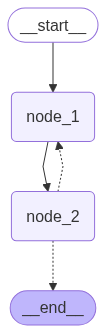

In [ ]:
from dotenv import load_dotenv, find_dotenv
from typing import TypedDict, Annotated, Literal
import operator
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import display, Image
from pprint import pprint

_ = load_dotenv(find_dotenv())

class AgentState(TypedDict):
    node: str
    scratch: str
    count: Annotated[int, operator.add]

def node_1(state: AgentState):
    print(f'node_1, count: {state['count']}')
    return {'node': 'node_1',
            'count': 1
            }

def node_2(state: AgentState):
    print (f'node_2, count: {state['count']}')
    return {'node': 'node_2',
            'count': 1
            }

def continueNot (state: AgentState) -> Literal['node_1', END]:
    return 'node_1' if state['count'] < 3 else END

builder = StateGraph(AgentState)
builder.add_node('node_1', node_1)
builder.add_node('node_2', node_2)

builder.set_entry_point('node_1')
builder.add_edge('node_1', 'node_2')
builder.add_conditional_edges('node_2', continueNot)

memory = MemorySaver()
graph = builder.compile(checkpointer = memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
thread = {'configurable': {'thread_id': '5'}}
graph.invoke({'scratch': 'Hi', 'count': 0}, thread)

node_1, count: 0
node_2, count: 1
node_1, count: 2
node_2, count: 3


{'node': 'node_2', 'scratch': 'Hi', 'count': 4}

##### **look at the current state**

In [ ]:
graph.get_state(thread)

StateSnapshot(values={'node': 'node_2', 'scratch': 'Hi', 'count': 4}, next=(), config={'configurable': {'thread_id': '5', 'checkpoint_ns': '', 'checkpoint_id': '1f03f5ad-1a9b-6325-8004-bcaaf0a33267'}}, metadata={'source': 'loop', 'writes': {'node_2': {'node': 'node_2', 'count': 1}}, 'step': 4, 'parents': {}, 'thread_id': '5'}, created_at='2025-06-02T02:39:34.565130+00:00', parent_config={'configurable': {'thread_id': '5', 'checkpoint_ns': '', 'checkpoint_id': '1f03f5ad-1a97-60cc-8003-246abaf2552e'}}, tasks=(), interrupts=())

##### **look at state history**

In [ ]:
for state in graph.get_state_history(thread):
    print(state, '\n')

StateSnapshot(values={'node': 'node_2', 'scratch': 'Hi', 'count': 4}, next=(), config={'configurable': {'thread_id': '5', 'checkpoint_ns': '', 'checkpoint_id': '1f03f5ad-1a9b-6325-8004-bcaaf0a33267'}}, metadata={'source': 'loop', 'writes': {'node_2': {'node': 'node_2', 'count': 1}}, 'step': 4, 'parents': {}, 'thread_id': '5'}, created_at='2025-06-02T02:39:34.565130+00:00', parent_config={'configurable': {'thread_id': '5', 'checkpoint_ns': '', 'checkpoint_id': '1f03f5ad-1a97-60cc-8003-246abaf2552e'}}, tasks=(), interrupts=()) 

StateSnapshot(values={'node': 'node_1', 'scratch': 'Hi', 'count': 3}, next=('node_2',), config={'configurable': {'thread_id': '5', 'checkpoint_ns': '', 'checkpoint_id': '1f03f5ad-1a97-60cc-8003-246abaf2552e'}}, metadata={'source': 'loop', 'writes': {'node_1': {'node': 'node_1', 'count': 1}}, 'step': 3, 'parents': {}, 'thread_id': '5'}, created_at='2025-06-02T02:39:34.563432+00:00', parent_config={'configurable': {'thread_id': '5', 'checkpoint_ns': '', 'checkpoint

In [ ]:
states = []
for state in graph.get_state_history(thread):
    states.append(state.config)
    print(state.config, state.values['count'])

{'configurable': {'thread_id': '5', 'checkpoint_ns': '', 'checkpoint_id': '1f03f5ad-1a9b-6325-8004-bcaaf0a33267'}} 4
{'configurable': {'thread_id': '5', 'checkpoint_ns': '', 'checkpoint_id': '1f03f5ad-1a97-60cc-8003-246abaf2552e'}} 3
{'configurable': {'thread_id': '5', 'checkpoint_ns': '', 'checkpoint_id': '1f03f5ad-1a95-6295-8002-650780fac446'}} 2
{'configurable': {'thread_id': '5', 'checkpoint_ns': '', 'checkpoint_id': '1f03f5ad-1a90-6110-8001-90f0a8702f71'}} 1
{'configurable': {'thread_id': '5', 'checkpoint_ns': '', 'checkpoint_id': '1f03f5ad-1a8a-6fe8-8000-fd64038c8e4a'}} 0
{'configurable': {'thread_id': '5', 'checkpoint_ns': '', 'checkpoint_id': '1f03f5ad-1a87-61ec-bfff-d73a81415db2'}} 0


##### **go back in time**

In [16]:
graph.invoke(None, states[-3])

node_2, count: 1
node_1, count: 2
node_2, count: 3


{'node': 'node_2', 'scratch': 'Hi', 'count': 4}

##### **modify state**

In [17]:
save_state = graph.get_state(states[-2])
save_state

StateSnapshot(values={'scratch': 'Hi', 'count': 0}, next=('node_1',), config={'configurable': {'thread_id': '5', 'checkpoint_ns': '', 'checkpoint_id': '1f03f5ad-1a8a-6fe8-8000-fd64038c8e4a'}}, metadata={'source': 'loop', 'writes': None, 'step': 0, 'parents': {}, 'thread_id': '5'}, created_at='2025-06-02T02:39:34.558467+00:00', parent_config={'configurable': {'thread_id': '5', 'checkpoint_ns': '', 'checkpoint_id': '1f03f5ad-1a87-61ec-bfff-d73a81415db2'}}, tasks=(PregelTask(id='7accbece-3b8a-4584-2f52-5ce6e9f715a8', name='node_1', path=('__pregel_pull', 'node_1'), error=None, interrupts=(), state=None, result={'node': 'node_1', 'count': 1}),), interrupts=())

In [ ]:
save_state.values['scratch'] = 'Hello'
save_state.values['count'] = -2

save_state

StateSnapshot(values={'scratch': 'Hello', 'count': -2}, next=('node_1',), config={'configurable': {'thread_id': '5', 'checkpoint_ns': '', 'checkpoint_id': '1f03f5ad-1a8a-6fe8-8000-fd64038c8e4a'}}, metadata={'source': 'loop', 'writes': None, 'step': 0, 'parents': {}, 'thread_id': '5'}, created_at='2025-06-02T02:39:34.558467+00:00', parent_config={'configurable': {'thread_id': '5', 'checkpoint_ns': '', 'checkpoint_id': '1f03f5ad-1a87-61ec-bfff-d73a81415db2'}}, tasks=(PregelTask(id='7accbece-3b8a-4584-2f52-5ce6e9f715a8', name='node_1', path=('__pregel_pull', 'node_1'), error=None, interrupts=(), state=None, result={'node': 'node_1', 'count': 1}),), interrupts=())

In [26]:
graph.update_state(thread, save_state.values)

{'configurable': {'thread_id': '5',
  'checkpoint_ns': '',
  'checkpoint_id': '1f03f5ad-1b66-639a-8005-43eabf3aac1b'}}

In [27]:
for i, state in enumerate(graph.get_state_history(thread)):
    if i >= 3:  # print latest 3 states
        break
    print(state, '\n')

StateSnapshot(values={'node': 'node_2', 'scratch': 'Hello', 'count': 2}, next=('node_1',), config={'configurable': {'thread_id': '5', 'checkpoint_ns': '', 'checkpoint_id': '1f03f5ad-1b66-639a-8005-43eabf3aac1b'}}, metadata={'source': 'update', 'writes': {'node_2': {'scratch': 'Hello', 'count': -2}}, 'step': 5, 'parents': {}, 'thread_id': '5'}, created_at='2025-06-02T02:39:34.648292+00:00', parent_config={'configurable': {'thread_id': '5', 'checkpoint_ns': '', 'checkpoint_id': '1f03f5ad-1b18-62ee-8004-3bf81ddce880'}}, tasks=(PregelTask(id='46788768-d9fe-02d8-a2d4-93a30a034c97', name='node_1', path=('__pregel_pull', 'node_1'), error=None, interrupts=(), state=None, result=None),), interrupts=()) 

StateSnapshot(values={'node': 'node_2', 'scratch': 'Hi', 'count': 4}, next=(), config={'configurable': {'thread_id': '5', 'checkpoint_ns': '', 'checkpoint_id': '1f03f5ad-1b18-62ee-8004-3bf81ddce880'}}, metadata={'source': 'loop', 'writes': {'node_2': {'node': 'node_2', 'count': 1}}, 'step': 4, 